In [ ]:
!pip install -q transformers datasets librosa evaluate jiwer gradio
!pip install -q peft "bitsandbytes>=0.46.1" accelerate
!pip install -q optimum optimum-intel openvino

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/1

In [ ]:
import os
import gc
import glob
import torch
from dataclasses import dataclass
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Union
from datasets import load_from_disk
from google.colab import drive
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    BitsAndBytesConfig
)

In [ ]:
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/whisper_fa_dataset"
PROCESSED_PATH = f"{BASE_DIR}/processed"
CHECKPOINT_DIR = f"{BASE_DIR}/models"

if not os.path.exists(f"{PROCESSED_PATH}/train"):
    raise FileNotFoundError("error ")

train_ds = load_from_disk(f"{PROCESSED_PATH}/train")
validation_ds = load_from_disk(f"{PROCESSED_PATH}/validation")
print('Done')

Mounted at /content/drive


Loading dataset from disk:   0%|          | 0/87 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/33 [00:00<?, ?it/s]

Done


In [ ]:
#checkpoints
!ls -lh /content/drive/MyDrive/whisper_fa_dataset/models/

total 8.0K
drwx------ 2 root root 4.0K Jun 20 09:10 checkpoint-800
drwx------ 2 root root 4.0K Jun 20 11:48 checkpoint-900


In [ ]:
# تنظیمات پردازش و مدل
processor = WhisperProcessor.from_pretrained("openai/whisper-large-v3-turbo", language="Persian", task="transcribe")

#Padding
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

#Quantization
print("Loading 8bit model ")
quantization_config = BitsAndBytesConfig(load_in_8bit=True)
model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-large-v3-turbo",
    quantization_config=quantization_config,
    device_map="auto"
)

#Lora
print("Lora")
model = prepare_model_for_kbit_training(model)
config = LoraConfig(r=32, lora_alpha=64, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none")
model = get_peft_model(model, config)
model.config.use_cache = False

#Trainer
print("تنظیم پارامترهای آموزش")
training_args = Seq2SeqTrainingArguments(
    output_dir=CHECKPOINT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-3,
    max_steps=1000,
    fp16=True,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    logging_steps=100,
    remove_unused_columns=False,
    label_names=["labels"],
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_ds,
    eval_dataset=validation_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
)

#checkpoints
print("-" * 40)
checkpoints = [d for d in glob.glob(f"{CHECKPOINT_DIR}/checkpoint-*") if os.path.isdir(d)]

if len(checkpoints) > 0:
    print(f"checkpoint found: {checkpoints}")
    trainer.train(resume_from_checkpoint=True)
else:
    print("checkpoints not found")
    trainer.train()

model.save_pretrained(f"{BASE_DIR}/final_lora_model")
print("Training finished")

Loading 8bit model 


model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

Lora
تنظیم پارامترهای آموزش
----------------------------------------
checkpoint found: ['/content/drive/MyDrive/whisper_fa_dataset/models/checkpoint-800', '/content/drive/MyDrive/whisper_fa_dataset/models/checkpoint-900']


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss,Validation Loss


Step,Training Loss,Validation Loss
1000,0.533144,0.238728


Training finished


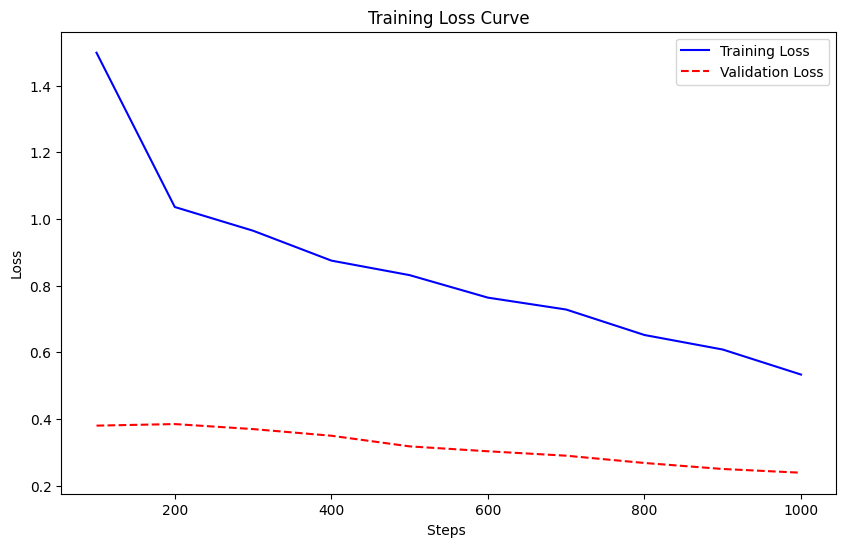

In [ ]:
log_history = trainer.state.log_history

steps_train = [x['step'] for x in log_history if 'loss' in x]
loss_train = [x['loss'] for x in log_history if 'loss' in x]

steps_eval = [x['step'] for x in log_history if 'eval_loss' in x]
loss_eval = [x['eval_loss'] for x in log_history if 'eval_loss' in x]


plt.figure(figsize=(10, 6))
plt.plot(steps_train, loss_train, label='Training Loss', color='blue', linestyle='-')
plt.plot(steps_eval, loss_eval, label='Validation Loss', color='red', linestyle='--')
plt.title('Training Loss Curve')
plt.xlabel('Steps ')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.4 MB/s eta 0:00:00


In [ ]:
%%bash
# تنظیم مسیرها

BASE_DIR="/content/drive/MyDrive/whisper_fa_dataset"
LORA_MODEL_ID="${BASE_DIR}/final_lora_model"
MERGED_MODEL_DIR="${BASE_DIR}/merged_model"
GGUF_OUTPUT_DIR="${BASE_DIR}/gguf_models"

mkdir -p $MERGED_MODEL_DIR
mkdir -p $GGUF_OUTPUT_DIR
mkdir -p /content/whisper.cpp/models/whisper-fa

#ادغام مدل
echo "Model integration"
python3 -c "
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import PeftModel

print('Base model...')
base_model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-large-v3-turbo', torch_dtype=torch.float16, device_map='cpu')

print('Combined with lora...')
model = PeftModel.from_pretrained(base_model, '${LORA_MODEL_ID}')
model = model.merge_and_unload()
print('Saving merged model...')
model.save_pretrained('${MERGED_MODEL_DIR}')

processor = WhisperProcessor.from_pretrained('openai/whisper-large-v3-turbo', language='Persian', task='transcribe')
processor.save_pretrained('${MERGED_MODEL_DIR}')
print('Integration completed successfully!')
"


if [ $? -ne 0 ]; then
  echo "خطا در مرحله ادغام مدل!"
  exit 1
fi


echo "Download tools"
cd /content
if [ ! -d "whisper.cpp" ]; then
  git clone https://github.com/ggerganov/whisper.cpp.git
fi
cd whisper.cpp




if [ ! -d "/content/whisper" ]; then
  git clone https://github.com/openai/whisper.git /content/whisper
fi


echo "Convert to GGML"
python3 models/convert-h5-to-ggml.py $MERGED_MODEL_DIR /content/whisper /content/whisper.cpp/models/whisper-fa

GGML_FILE=$(ls /content/whisper.cpp/models/whisper-fa/ggml-model*.bin | head -n 1)

if [ -z "$GGML_FILE" ]; then
  echo "Error: GGML not found"
  exit 1
fi

echo "File found: $GGML_FILE"


echo "Quantization & CPU "
if [ -f "./quantize" ]; then
    ./quantize "$GGML_FILE" ${GGUF_OUTPUT_DIR}/ggml-model-fa-q8_0.bin q8_0
elif [ -f "./whisper-quantize" ]; then
    ./whisper-quantize "$GGML_FILE" ${GGUF_OUTPUT_DIR}/ggml-model-fa-q8_0.bin q8_0
else
    echo "Error: Quantize tool not found!"
    exit 1
fi

echo "----------------------------------------"
echo " Done Model ready "
echo "path: ${GGUF_OUTPUT_DIR}/ggml-model-fa-q8_0.bin"

In [ ]:
%%bash
# ۱. نصب پیش‌نیازها
pip install -q -U torchao gguf safetensors transformers

# ۲. تنظیم مسیرهای اصلی پروژه در درایو
BASE_DIR="/content/drive/MyDrive/whisper_fa_dataset"
MERGED_MODEL_DIR="${BASE_DIR}/merged_model"
GGUF_OUTPUT_DIR="${BASE_DIR}/gguf_models"

mkdir -p $GGUF_OUTPUT_DIR

# 🟢 بخش جدید: تعمیر فایل‌های جاافتاده در پوشه مدل
echo "در حال بررسی و تکمیل فایل‌های مدل ادغام‌شده..."
python3 -c "
import os
from transformers import WhisperProcessor

# اگر فایل کلمات وجود نداشت، آن را دانلود می‌کنیم
if not os.path.exists('${MERGED_MODEL_DIR}/vocab.json'):
    print('⚠️ فایل vocab.json پیدا نشد. در حال دانلود فایل‌های پردازشگر...')
    processor = WhisperProcessor.from_pretrained('openai/whisper-large-v3-turbo', language='Persian', task='transcribe')
    processor.save_pretrained('${MERGED_MODEL_DIR}')
    print('✅ فایل‌ها با موفقیت به پوشه مدل اضافه شدند.')
else:
    print('✅ تمام فایل‌های مدل کامل هستند.')
"

# ۳. پاک‌سازی محیط از اجراهای قبلی
echo "در حال پاک‌سازی محیط..."
cd /content
rm -rf whisper.cpp
rm -rf whisper

# ۴. دانلود و کامپایل ابزار whisper.cpp
echo "در حال دانلود ابزار whisper.cpp..."
git clone https://github.com/ggerganov/whisper.cpp.git
cd whisper.cpp

echo "در حال کامپایل ابزارها (Make)..."
make

# ۵. دانلود مخزن اصلی OpenAI Whisper (پیش‌نیاز تبدیل)
echo "در حال دریافت مخزن اصلی Whisper..."
cd /content
git clone https://github.com/openai/whisper.git

# ۶. تبدیل مدل به فرمت پایه (GGML)
echo "در حال تبدیل مدل به فرمت GGML..."
cd /content/whisper.cpp
mkdir -p models/whisper-fa

# پیدا کردن اسکریپت تبدیل
CONVERT_SCRIPT=$(ls models/convert-h5-to-ggml.py models/convert-hf-to-ggml.py models/convert-pt-to-ggml.py 2>/dev/null | head -n 1)

if [ -z "$CONVERT_SCRIPT" ]; then
    echo "⚠️ اسکریپت پیدا نشد، در حال دانلود نسخه پایدار..."
    wget -q https://raw.githubusercontent.com/ggerganov/whisper.cpp/master/models/convert-h5-to-ggml.py -O models/convert-h5-to-ggml.py
    CONVERT_SCRIPT="models/convert-h5-to-ggml.py"
fi

echo "✅ استفاده از اسکریپت: $CONVERT_SCRIPT"

# اجرای فرآیند تبدیل
python3 $CONVERT_SCRIPT $MERGED_MODEL_DIR /content/whisper /content/whisper.cpp/models/whisper-fa

# بررسی ساخته شدن فایل تبدیل‌شده
GGML_FILE=$(ls models/whisper-fa/ggml-model*.bin models/whisper-fa/*.gguf 2>/dev/null | head -n 1)

if [ -z "$GGML_FILE" ]; then
  echo "❌ خطا: فایل پایه GGML تولید نشد! لطفاً لاگ‌های بالا را بررسی کنید."
  exit 1
fi

echo "✅ فایل پایه با موفقیت تولید شد: $GGML_FILE"

# ۷. فشرده‌سازی مدل برای اجرا روی CPU
echo "در حال کوانتایز و بهینه‌سازی مدل برای پردازنده‌های معمولی (Q8_0)..."

QUANTIZE_TOOL=""
if [ -f "./whisper-quantize" ]; then
    QUANTIZE_TOOL="./whisper-quantize"
elif [ -f "./quantize" ]; then
    QUANTIZE_TOOL="./quantize"
elif [ -f "build/bin/whisper-quantize" ]; then
    QUANTIZE_TOOL="build/bin/whisper-quantize"
fi

if [ -n "$QUANTIZE_TOOL" ]; then
    # اجرای فشرده‌سازی و ذخیره مستقیم در گوگل درایو
    $QUANTIZE_TOOL "$GGML_FILE" ${GGUF_OUTPUT_DIR}/whisper-fa-q8_0.bin q8_0
    echo "----------------------------------------"
    echo "🎉 تبریک! همه مراحل با موفقیت به پایان رسید."
    echo "مدل نهایی، فوق‌سبک و بهینه‌شده‌ی شما در گوگل درایو ذخیره شد."
    echo "📁 مسیر فایل شما: ${GGUF_OUTPUT_DIR}/whisper-fa-q8_0.bin"
else
    echo "❌ خطا: فایل اجرایی کوانتایز در سیستم پیدا نشد."
fi

In [ ]:
%%bash
# تنظیم مسیرها
BASE_DIR="/content/drive/MyDrive/whisper_fa_dataset"
MERGED_MODEL_DIR="${BASE_DIR}/merged_model"
GGUF_OUTPUT_DIR="${BASE_DIR}/gguf_models"

# ۱. دانلود تمام فایل‌های جانبی ممکن برای راضی کردن اسکریپت
echo "در حال دریافت تمام فایل‌های تنظیمات و توکنایزر..."
FILES=(
    "added_tokens.json"
    "special_tokens_map.json"
    "normalizer.json"
    "preprocessor_config.json"
    "vocab.json"
    "config.json"
    "tokenizer.json"
    "merges.txt"
    "generation_config.json"
)

for FILE in "${FILES[@]}"; do
    wget -q "https://huggingface.co/openai/whisper-large-v3-turbo/resolve/main/${FILE}" -O "${MERGED_MODEL_DIR}/${FILE}"
done

echo "✅ تمام فایل‌های جانبی با موفقیت در پوشه مدل قرار گرفتند."

# ورود به پوشه نرم‌افزار
cd /content/whisper.cpp

# ۲. اجرای اسکریپت تبدیل
echo "در حال تبدیل مدل به فرمت GGML..."
CONVERT_SCRIPT=$(ls models/convert-h5-to-ggml.py models/convert-hf-to-ggml.py 2>/dev/null | head -n 1)

python3 $CONVERT_SCRIPT $MERGED_MODEL_DIR /content/whisper /content/whisper.cpp/models/whisper-fa

# بررسی وضعیت تبدیل
GGML_FILE=$(ls models/whisper-fa/ggml-model*.bin 2>/dev/null | head -n 1)

if [ -z "$GGML_FILE" ]; then
  echo "❌ خطا: تبدیل انجام نشد. لطفاً لاگ‌های بالا را چک کنید."
  exit 1
fi
echo "✅ مدل با موفقیت تبدیل شد!"

# ۳. کوانتایز و فشرده‌سازی برای CPU
echo "در حال فشرده‌سازی (Q8_0) برای پردازنده (CPU)..."
QUANTIZE_TOOL=$(find . -maxdepth 2 -name "*quantize" -executable | grep -v "\.py" | head -n 1)

if [ -n "$QUANTIZE_TOOL" ]; then
    $QUANTIZE_TOOL "$GGML_FILE" ${GGUF_OUTPUT_DIR}/whisper-fa-q8_0.bin q8_0
    echo "----------------------------------------"
    echo "🎉 تبریک! سد نهایی شکسته شد."
    echo "📁 فایل نهایی درایو شما آماده است: ${GGUF_OUTPUT_DIR}/whisper-fa-q8_0.bin"
else
    echo "❌ خطا: ابزار فشرده‌سازی پیدا نشد."
fi

در حال دریافت تمام فایل‌های تنظیمات و توکنایزر...
✅ تمام فایل‌های جانبی با موفقیت در پوشه مدل قرار گرفتند.
در حال تبدیل مدل به فرمت GGML...
model.encoder.conv1.weight  ->  encoder.conv1.weight
encoder.conv1.weight 3 (1280, 128, 3)
model.encoder.conv1.bias  ->  encoder.conv1.bias
  Reshaped variable:  encoder.conv1.bias  to shape:  (1280, 1)
encoder.conv1.bias 2 (1280, 1)
  Converting to float32
model.encoder.conv2.weight  ->  encoder.conv2.weight
encoder.conv2.weight 3 (1280, 1280, 3)
model.encoder.conv2.bias  ->  encoder.conv2.bias
  Reshaped variable:  encoder.conv2.bias  to shape:  (1280, 1)
encoder.conv2.bias 2 (1280, 1)
  Converting to float32
model.encoder.embed_positions.weight  ->  encoder.positional_embedding
encoder.positional_embedding 2 (1500, 1280)
  Converting to float32
model.encoder.layers.0.self_attn.k_proj.weight  ->  encoder.blocks.0.attn.key.weight
encoder.blocks.0.attn.key.weight 2 (1280, 1280)
model.encoder.layers.0.self_attn.v_proj.weight  ->  encoder.blocks.0.at

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Loading weights: 100%|██████████| 587/587 [00:22<00:00, 25.55it/s]
bash: line 49: ./examples/parakeet-quantize: Is a directory


In [ ]:
%%bash
# تنظیم مسیرها
BASE_DIR="/content/drive/MyDrive/whisper_fa_dataset"
GGUF_OUTPUT_DIR="${BASE_DIR}/gguf_models"
GGML_FILE="/content/whisper.cpp/models/whisper-fa/ggml-model.bin"

cd /content/whisper.cpp

echo "در حال جستجوی فایل برنامه‌ی فشرده‌ساز (و نه پوشه‌ها!)..."
# این بار فقط به دنبال فایل‌های اجرایی می‌گردیم و پوشه parakeet را هم خط می‌زنیم
QUANTIZE_TOOL=$(find . -type f -name "*quantize" -executable | grep -v "parakeet" | head -n 1)

if [ -z "$QUANTIZE_TOOL" ]; then
    echo "❌ ابزار پیدا نشد. لطفاً مطمئن شوید کولب ری‌استارت نشده است."
    exit 1
fi

echo "✅ ابزار پیدا شد: $QUANTIZE_TOOL"
echo "در حال ساخت مدل نهایی..."

# اجرای فشرده‌سازی
$QUANTIZE_TOOL $GGML_FILE ${GGUF_OUTPUT_DIR}/whisper-fa-q8_0.bin q8_0

echo "----------------------------------------"
echo "🎉 کار تمام است! مدل شما با موفقیت فشرده شد."
echo "می‌توانید به گوگل درایو خود بروید و فایل whisper-fa-q8_0.bin را دانلود کنید."

در حال جستجوی فایل برنامه‌ی فشرده‌ساز (و نه پوشه‌ها!)...
✅ ابزار پیدا شد: ./build/bin/whisper-quantize
در حال ساخت مدل نهایی...
whisper_model_quantize: loading model from '/content/whisper.cpp/models/whisper-fa/ggml-model.bin'
                                            encoder.conv1.weight - [    3,   128,  1280], type =    f16 size =    0.938 MB
                                              encoder.conv1.bias - [    1,  1280,     1], type =    f32 size =    0.005 MB
                                            encoder.conv2.weight - [    3,  1280,  1280], type =    f16 size =    9.375 MB
                                              encoder.conv2.bias - [    1,  1280,     1], type =    f32 size =    0.005 MB
                                    encoder.positional_embedding - [ 1280,  1500,     1], type =    f32 size =    7.324 MB
                                encoder.blocks.0.attn.key.weight - [ 1280,  1280,     1], type =    f16 size =     6.25 MB ->     1.66 MB
                    

whisper_model_quantize: n_vocab       = 51866
whisper_model_quantize: n_audio_ctx   = 1500
whisper_model_quantize: n_audio_state = 1280
whisper_model_quantize: n_audio_head  = 20
whisper_model_quantize: n_audio_layer = 32
whisper_model_quantize: n_text_ctx    = 448
whisper_model_quantize: n_text_state  = 1280
whisper_model_quantize: n_text_head   = 20
whisper_model_quantize: n_text_layer  = 4
whisper_model_quantize: n_mels        = 128
whisper_model_quantize: ftype (src)   = 1
whisper_model_quantize: qntvr (src)   = 0
whisper_model_quantize: ftype (dst)   = 2007
whisper_model_quantize: qntvr (dst)   = 2
